# Predicting MTA Elevator and Escalator Outages

## Project Overview

Elevators and escalators are important parts of New York City's subway system, particularly for riders who depend on accessible station infrastructure. Unscheduled outages can disrupt service and reduce accessibility.

This project explores **predictive maintenance**, approach that uses historical and current equipment data to identify when equipment may be at risk of failure, allowing maintenance to be prioritized before a breakdown occurs.

Using historical MTA elevator and escalator performance data, this project examines whether current and previous equipment conditions can help predict future outages. Rather than only analyzing outages after they occur, the goal is to predict whether an elevator or escalator will experience an **unscheduled outage in the following month**.

SOURCE: https://data.ny.gov/Transportation/MTA-NYCT-Subway-Elevator-and-Escalator-Availabilit/rc78-7x78/about_data

## Prediction Goal

**Using information available for an elevator or escalator this month, can we predict whether it will experience at least one unscheduled outage next month?**

Each observation represents one piece of equipment during one month. The target variable is:

- **0:** No unscheduled outage in the following month
- **1:** At least one unscheduled outage in the following month

Predictor variables include equipment characteristics and operational measures such as equipment type, borough, scheduled and unscheduled outages, entrapments, time since major improvement, availability, and previous month outage history.

The broader predictive maintenance goal is to identify equipment with near term outage risk so that maintenance and inspection resources could potentially be prioritized before an outage occurs.

In [64]:
# Import pandas for working with tabular data
import pandas as pd
# Import NumPy for numerical operations and NaN values
import numpy as np
# Import Matplotlib for data visualizations
import matplotlib.pyplot as plt

In [65]:
# Load the original MTA elevator and escalator monthly performance dataset
df = pd.read_csv(
    "MTA_NYCT_Subway_Elevator_and_Escalator_Availability__Beginning_2015_20260922.csv"
)

## Initial Data Exploration, EDA DATA CLEANING

In [66]:
# Display the first five rows to understand the structure of the dataset
df.head()

,Month,Borough,Equipment Type,Equipment Code,Total Outages,Scheduled Outages,Unscheduled Outages,Entrapments,Time Since Major Improvement,AM Peak Availability,...,PM Peak Availability,PM Peak Hours Available,PM Peak Total Hours,24-Hour Availability,24-Hour Hours Available,24-Hour Total Hours,Station Name,Station MRN,Station Complex Name,Station Complex MRN
0,01/01/2015,Queens,Elevator,EL426,2,2,0,0,95.0,100%,...,100%,124.000000,124.0,98.60215053763%,733.600000,744.0,JUNCTIONBLVD-FLS-7,451,Junction Blvd - Station,451
1,01/01/2015,Queens,Elevator,EL411,6,5,1,0,313.0,98.46774193548%,...,98.15860215054%,121.716667,124.0,96.25224014337%,716.116667,744.0,SUTPHINBLVD-ARCHERAV-JFKAIRPORT-QBL-E/J/Z,279,Sutphin Blvd-Archer Av-JFK Airport - Station,279
2,01/01/2015,Brooklyn,Escalator,ES332,16,3,13,0,1039.0,95.81989247312%,...,90.33602150538%,112.016667,124.0,93.26836917563%,693.916667,744.0,MYRTLE-WYCKOFFAVS-MYT-M,112,"Myrtle-Wyckoff Avs (L,M)",630
3,01/01/2015,Queens,Elevator,EL449X,0,0,0,0,NaN,100%,...,100%,124.000000,124.0,100%,744.000000,744.0,SUTPHINBLVD-ARCHERAV-JFKAIRPORT-QBL-E/J/Z,279,Sutphin Blvd-Archer Av-JFK Airport - Station,279
4,01/01/2015,Manhattan,Escalator,ES239,7,3,4,0,655.0,97.88978494624%,...,97.37903225806%,120.750000,124.0,96.4314516129%,717.450000,744.0,5AV/53ST-QBL-E/M,276,5 Av/53 St - Station,276


In [67]:
# Check the number of rows and columns
df.shape

(82385, 22)

In [68]:
# View all original column names
df.columns

Index(['Month', 'Borough', 'Equipment Type', 'Equipment Code', 'Total Outages',
       'Scheduled Outages', 'Unscheduled Outages', 'Entrapments',
       'Time Since Major Improvement', 'AM Peak Availability',
       'AM Peak Hours Available', 'AM Peak Total Hours',
       'PM Peak Availability', 'PM Peak Hours Available',
       'PM Peak Total Hours', '24-Hour Availability',
       '24-Hour Hours Available', '24-Hour Total Hours', 'Station Name',
       'Station MRN', 'Station Complex Name', 'Station Complex MRN'],
      dtype='object')

In [69]:
# Review column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82385 entries, 0 to 82384
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         82385 non-null  object 
 1   Borough                       82385 non-null  object 
 2   Equipment Type                82385 non-null  object 
 3   Equipment Code                82385 non-null  object 
 4   Total Outages                 82385 non-null  int64  
 5   Scheduled Outages             82385 non-null  int64  
 6   Unscheduled Outages           82385 non-null  int64  
 7   Entrapments                   82385 non-null  int64  
 8   Time Since Major Improvement  69733 non-null  float64
 9   AM Peak Availability          79828 non-null  object 
 10  AM Peak Hours Available       82385 non-null  float64
 11  AM Peak Total Hours           82385 non-null  float64
 12  PM Peak Availability          79845 non-null  object 
 13  P

found that month is stored as an object and all the availabilty percentages are stored as objects 

In [70]:
# Count missing values in each column
df.isnull().sum()

Month                               0
Borough                             0
Equipment Type                      0
Equipment Code                      0
Total Outages                       0
Scheduled Outages                   0
Unscheduled Outages                 0
Entrapments                         0
Time Since Major Improvement    12652
AM Peak Availability             2557
AM Peak Hours Available             0
AM Peak Total Hours                 0
PM Peak Availability             2540
PM Peak Hours Available             0
PM Peak Total Hours                 0
24-Hour Availability             2528
24-Hour Hours Available             0
24-Hour Total Hours                 0
Station Name                        0
Station MRN                         0
Station Complex Name                0
Station Complex MRN                 0
dtype: int64

In [71]:
# Check whether any rows are exact duplicates
df.duplicated().sum()

np.int64(0)

## Understand the unit of observation EDA CONTINUED

In [72]:
# Count equipment month records with and without an unscheduled outage.
# The number of unplanned or unexpected interruptions of elevator or escalator service.
(df["Unscheduled Outages"] > 0).value_counts()

Unscheduled Outages
True     53112
False    29273
Name: count, dtype: int64

In [73]:
# Count the number of unique elevators and escalators in the dataset
# 695 machines observed repeatedly across months.
df["Equipment Code"].nunique()

695

In [74]:
# Summarize how many monthly records are available for each piece of equipment
# The median equipment has 139 monthly records, about 11.5 years of history
df.groupby("Equipment Code").size().describe()

count    695.000000
mean     118.539568
std       38.177740
min        2.000000
25%      115.000000
50%      139.000000
75%      139.000000
max      139.000000
dtype: float64

the dataset contains about 82,000 records, but those aren't 82,000 different machines. There are 695 unique elevators and escalators, and each machine is observed repeatedly over time. Each row represents one machine during one month. On average, each machine has about 119 monthly observations, which gives us the roughly 82,000 total records.

In [75]:
# Verify that each equipment code has only one record per month
# One row represents one piece of equipment during one month.
df.duplicated(
    subset=["Equipment Code", "Month"]
).sum()

np.int64(0)

# Clean

In [76]:
# Creating a copy for cleaning and feature engineering
# This preserves df as the original raw dataset
clean_df = df.copy()

In [77]:
# Convert Month from text to a datetime data type
clean_df["Month"] = pd.to_datetime(clean_df["Month"])

# Confirm that the conversion worked
clean_df["Month"].dtype

dtype('<M8[ns]')

In [78]:
# Check the first and last months represented in the dataset
clean_df["Month"].min(), clean_df["Month"].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2026-07-01 00:00:00'))

In [79]:
# Count the number of equipment month records available in each year
clean_df["Month"].dt.year.value_counts().sort_index()

Month
2015    5873
2016    6004
2017    6621
2018    6742
2019    6926
2020    7065
2021    7415
2022    7488
2023    7560
2024    7807
2025    8076
2026    4808
Name: count, dtype: int64

In [80]:
# Availability columns are stored as strings because they contain a % sign
availability_cols = [
    "AM Peak Availability",
    "PM Peak Availability",
    "24-Hour Availability"
]

# Remove the % sign and convert the columns to numeric values
for col in availability_cols:
    clean_df[col] = (
        clean_df[col]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

In [81]:
# Sort each piece of equipment chronologically so monthly history is in the correct order
clean_df = clean_df.sort_values(
    ["Equipment Code", "Month"]
).reset_index(drop=True)

In [82]:
# Preview one equipment's records to confirm that the months are chronological
clean_df[[
    "Equipment Code",
    "Month",
    "Unscheduled Outages"
]].head(20)

,Equipment Code,Month,Unscheduled Outages
0,EL103,2015-01-01,8
1,EL103,2015-02-01,4
2,EL103,2015-03-01,4
3,EL103,2015-04-01,1
4,EL103,2015-05-01,4
5,EL103,2015-06-01,5
6,EL103,2015-07-01,7
7,EL103,2015-08-01,1
8,EL103,2015-09-01,10
9,EL103,2015-10-01,10


In [83]:
# Temporarily identify the next recorded month for each piece of equipment
clean_df["Next Month"] = (
    clean_df.groupby("Equipment Code")["Month"].shift(-1)
)

# Calculate the number of calendar months between consecutive records
clean_df["Month Gap"] = (
    clean_df["Next Month"].dt.to_period("M")
    - clean_df["Month"].dt.to_period("M")
).apply(lambda x: x.n if pd.notna(x) else np.nan)

# Verify that consecutive equipment records are exactly one month apart
clean_df["Month Gap"].value_counts().sort_index()

Month Gap
1.0    81690
Name: count, dtype: int64

In [84]:
# Move each equipment's next month unscheduled outage count onto the current month's row
clean_df["Outages Next Month"] = (
    clean_df.groupby("Equipment Code")["Unscheduled Outages"].shift(-1)
)



In [85]:
# Verify that each row now contains the following month's outage count
clean_df[[
    "Equipment Code",
    "Month",
    "Unscheduled Outages",
    "Outages Next Month"
]].head(10)

,Equipment Code,Month,Unscheduled Outages,Outages Next Month
0,EL103,2015-01-01,8,4.0
1,EL103,2015-02-01,4,4.0
2,EL103,2015-03-01,4,1.0
3,EL103,2015-04-01,1,4.0
4,EL103,2015-05-01,4,5.0
5,EL103,2015-06-01,5,7.0
6,EL103,2015-07-01,7,1.0
7,EL103,2015-08-01,1,10.0
8,EL103,2015-09-01,10,10.0
9,EL103,2015-10-01,10,7.0


## Target Engineering

Convert the number of unscheduled outages in the following month into a binary classification target:

In [86]:
# Create the binary target:
# 1 = at least one unscheduled outage next month
# 0 = no unscheduled outages next month
# NaN = next month's data is unavailable
# np.where(condition, value_if_true, value_if_false)
clean_df["Future 1 Month Outage"] = np.where(
    clean_df["Outages Next Month"].isna(),
    np.nan,
    (clean_df["Outages Next Month"] > 0).astype(int)
)

# Target EDA , "Future 1-Month Outage"

In [87]:
# Count target classes and include rows where the next month is unavailable
# we have 695 unique equipment codes with nan which makes sense b/c we have 695 unique equipments 
# and equipment has one final observed month
clean_df["Future 1 Month Outage"].value_counts(dropna=False)

Future 1 Month Outage
1.0    52695
0.0    28995
NaN      695
Name: count, dtype: int64

The first observation for each machine doesn't have a previous month,  and the last observation doesn't have a following month for the target

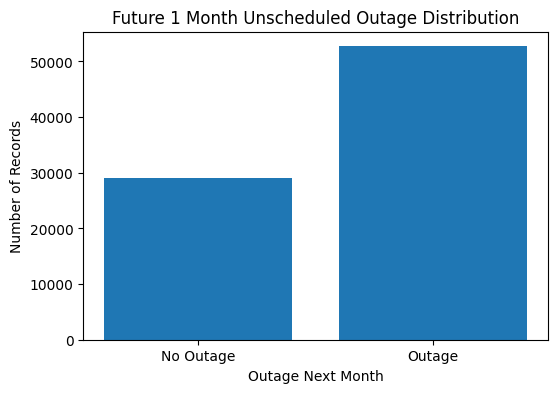

In [88]:
# Count the two target classes for visualization
target_counts = (
    clean_df["Future 1 Month Outage"]
    .value_counts()
    .sort_index()
)

# Create a bar chart of the target distribution
plt.figure(figsize=(6, 4))
plt.bar(["No Outage", "Outage"], target_counts.values)

# Add descriptive chart labels
plt.title("Future 1 Month Unscheduled Outage Distribution")
plt.xlabel("Outage Next Month")
plt.ylabel("Number of Records")

# Display the chart
plt.show()

In [89]:
# there are 45,145 elevator month observations and 37,240 escalator month observations.
clean_df["Equipment Type"].value_counts()

Equipment Type
Elevator     45145
Escalator    37240
Name: count, dtype: int64

In [90]:
# Calculate the next month outage rate for elevators and escalators
# Since the target is 0/1, its mean equals the proportion of records with target = 1
# 75.2% of eligible escalator month observations had at least one unscheduled outage in the following month.
clean_df.groupby("Equipment Type")["Future 1 Month Outage"].mean()

Equipment Type
Elevator     0.556313
Escalator    0.752476
Name: Future 1 Month Outage, dtype: float64

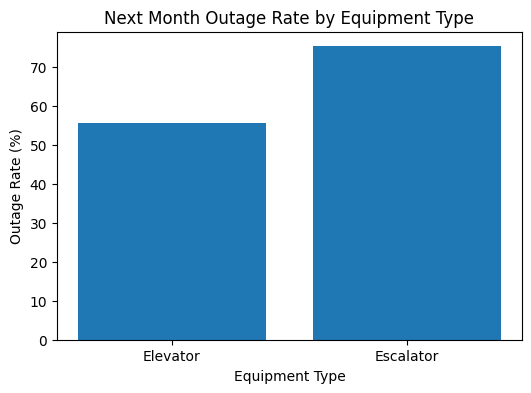

In [91]:
# Calculate next month outage percentages by equipment type
outage_rate = (
    clean_df.groupby("Equipment Type")["Future 1 Month Outage"]
    .mean() * 100
)

# Plot the outage percentages
plt.figure(figsize=(6, 4))
plt.bar(outage_rate.index, outage_rate.values)

# Add chart labels
plt.title("Next Month Outage Rate by Equipment Type")
plt.xlabel("Equipment Type")
plt.ylabel("Outage Rate (%)")

# Display the chart
plt.show()

In [92]:
# Compare the average number of current month unscheduled outages
# for equipment that did and did not have an outage the following month
clean_df.groupby(
    "Future 1 Month Outage"
)["Unscheduled Outages"].mean()

Future 1 Month Outage
0.0    0.643628
1.0    4.853819
Name: Unscheduled Outages, dtype: float64

to see whether the number of unscheduled outages in the current month was associated with the likelihood of an unscheduled outage in the following month. Equipment that experienced a future outage had substantially more current month outages on average.

## Feature Engineering

In [93]:
# Create a feature containing each machine's unscheduled outage count
# from the previous month
clean_df["Previous Month Outages"] = (
    clean_df.groupby("Equipment Code")["Unscheduled Outages"]
    .shift(1)
)

In [94]:
# Check that the previous month outage feature was created correctly
# Check that the previous month and next month outage values align correctly
clean_df[[
    "Equipment Code",
    "Month",
    "Previous Month Outages",
    "Unscheduled Outages",
    "Outages Next Month",
    "Future 1 Month Outage"
]].head(10)

,Equipment Code,Month,Previous Month Outages,Unscheduled Outages,Outages Next Month,Future 1 Month Outage
0,EL103,2015-01-01,NaN,8,4.0,1.0
1,EL103,2015-02-01,8.0,4,4.0,1.0
2,EL103,2015-03-01,4.0,4,1.0,1.0
3,EL103,2015-04-01,4.0,1,4.0,1.0
4,EL103,2015-05-01,1.0,4,5.0,1.0
5,EL103,2015-06-01,4.0,5,7.0,1.0
6,EL103,2015-07-01,5.0,7,1.0,1.0
7,EL103,2015-08-01,7.0,1,10.0,1.0
8,EL103,2015-09-01,1.0,10,10.0,1.0
9,EL103,2015-10-01,10.0,10,7.0,1.0


In [95]:
# Review summary statistics for the main numerical variables
clean_df[[
    "Scheduled Outages",
    "Unscheduled Outages",
    "Entrapments",
    "Time Since Major Improvement",
    "24-Hour Availability",
    "Previous Month Outages"
]].describe()

,Scheduled Outages,Unscheduled Outages,Entrapments,Time Since Major Improvement,24-Hour Availability,Previous Month Outages
count,82385.000000,82385.000000,82385.000000,69733.000000,79857.000000,81690.000000
mean,2.166839,3.354846,0.168429,343.227539,94.811320,3.359456
std,2.545726,5.136152,0.574986,323.840662,11.282549,5.144849
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,104.000000,95.333781,0.000000
50%,2.000000,1.000000,0.000000,226.000000,97.898148,1.000000
75%,3.000000,4.000000,0.000000,434.000000,99.069444,4.000000
max,35.000000,86.000000,12.000000,1453.000000,100.000000,86.000000


## Model Preparation

In [96]:
# Select the variables needed for modeling
features = [
    "Month",
    "Equipment Type",
    "Borough",
    "Scheduled Outages",
    "Unscheduled Outages",
    "Entrapments",
    "Time Since Major Improvement",
    "24-Hour Availability",
    "Previous Month Outages",
    "Future 1 Month Outage"
]

# Create a separate dataframe containing only the variables needed for modeling
model_df = clean_df[features].copy()

# Check the dimensions of the modeling dataframe
model_df.shape

(82385, 10)

In [97]:
# Check missing values in the modeling dataset
model_df.isnull().sum()

Month                               0
Equipment Type                      0
Borough                             0
Scheduled Outages                   0
Unscheduled Outages                 0
Entrapments                         0
Time Since Major Improvement    12652
24-Hour Availability             2528
Previous Month Outages            695
Future 1 Month Outage             695
dtype: int64

In [98]:
# Drop rows where the previous month feature or next month target is unavailable
# These are the first and last observations for each machine
#The first observation for each machine doesn't have a previous month, 
# and the last observation doesn't have a following month for the target, so those rows can't be used for modeling.
model_df = model_df.dropna(
    subset=[
        "Previous Month Outages",
        "Future 1 Month Outage"
    ]
).copy()

In [99]:
model_df.isnull().sum()

Month                               0
Equipment Type                      0
Borough                             0
Scheduled Outages                   0
Unscheduled Outages                 0
Entrapments                         0
Time Since Major Improvement    12264
24-Hour Availability             2490
Previous Month Outages              0
Future 1 Month Outage               0
dtype: int64

In [100]:
# Separate the predictor variables (X) from the target variable (y)
X = model_df[[
    "Equipment Type",
    "Borough",
    "Scheduled Outages",
    "Unscheduled Outages",
    "Entrapments",
    "Time Since Major Improvement",
    "24-Hour Availability",
    "Previous Month Outages"
]].copy()

# Define the target and convert the binary labels from 0.0/1.0 to integers
y = model_df["Future 1 Month Outage"].astype(int)

In [101]:
# Confirm that X and y contain the same number of observations
X.shape, y.shape

((80995, 8), (80995,))

In [102]:
# Convert categorical features into numeric dummy variables
X = pd.get_dummies(
    X,
    columns=["Equipment Type", "Borough"],
    drop_first=True,
    dtype=int
)

In [103]:
# Preview the predictor variables
X.head()

,Scheduled Outages,Unscheduled Outages,Entrapments,Time Since Major Improvement,24-Hour Availability,Previous Month Outages,Equipment Type_Escalator,Borough_Brooklyn,Borough_Manhattan,Borough_Queens
1,0,4,1,1061.0,94.605655,8.0,0,0,1,0
2,3,4,2,1062.0,94.852151,4.0,0,0,1,0
3,4,1,0,1063.0,94.907407,4.0,0,0,1,0
4,1,4,0,1064.0,98.131720,1.0,0,0,1,0
5,1,5,0,1065.0,26.930556,4.0,0,0,1,0


In [104]:
# Check the distribution of the binary target
y.value_counts()

Future 1 Month Outage
1    52233
0    28762
Name: count, dtype: int64

### Time-Based Train/Test Split

Because this project predicts whether an elevator or escalator will experience an unscheduled outage in the following month, the data is split chronologically rather than randomly.

Observations before 2025 are used to train the model, while observations from 2025 onward are reserved for testing. This allows the model to learn patterns from historical equipment data and then be evaluated on later, unseen observations.

This better reflects the predictive goal of the project: using information available in the past and current month to predict future outages.

In [105]:
# Use data before 2025 for training and data from 2025 onward for testing
train_mask = model_df["Month"] < "2025-01-01"
test_mask = model_df["Month"] >= "2025-01-01"

# Apply the time-based split to the predictor variables
X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

# Apply the same split to the target variable
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

Because this is a forecasting problem using monthly equipment data, I used a chronological split. I trained the model on historical observations before 2025 and tested it on observations from 2025 onward to better simulate predicting future outages from past data.

In [106]:
# Confirm the sizes of the training and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((68831, 10), (12164, 10), (68831,), (12164,))

In [107]:
# Check missing values in the training and test sets before imputation
print(X_train.isnull().sum())
print()
print(X_test.isnull().sum())

Scheduled Outages                   0
Unscheduled Outages                 0
Entrapments                         0
Time Since Major Improvement    10475
24-Hour Availability             1700
Previous Month Outages              0
Equipment Type_Escalator            0
Borough_Brooklyn                    0
Borough_Manhattan                   0
Borough_Queens                      0
dtype: int64

Scheduled Outages                  0
Unscheduled Outages                0
Entrapments                        0
Time Since Major Improvement    1789
24-Hour Availability             790
Previous Month Outages             0
Equipment Type_Escalator           0
Borough_Brooklyn                   0
Borough_Manhattan                  0
Borough_Queens                     0
dtype: int64


Some predictor values are missing, but the rows are still useful, so instead of dropping them, we replace the missing values with the median. The median is calculated only from the training data and then applied to both training and test data to keep the test period separate and avoid data leakage.

In [108]:
# Calculate the median from the training data only
train_median = X_train["Time Since Major Improvement"].median()

# Fill missing values in both sets using the training median
X_train["Time Since Major Improvement"] = (
    X_train["Time Since Major Improvement"].fillna(train_median)
)

X_test["Time Since Major Improvement"] = (
    X_test["Time Since Major Improvement"].fillna(train_median)
)


/var/folders/5m/lm5s5llx2ml81msrkdfrhm_h0000gn/T/ipykernel_10190/2082931209.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["Time Since Major Improvement"] = (
/var/folders/5m/lm5s5llx2ml81msrkdfrhm_h0000gn/T/ipykernel_10190/2082931209.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Time Since Major Improvement"] = (


In [109]:
# Calculate the median availability from the training data only
availability_median = X_train["24-Hour Availability"].median()

# Fill missing values in both sets using the training median
X_train["24-Hour Availability"] = (
    X_train["24-Hour Availability"].fillna(availability_median)
)

X_test["24-Hour Availability"] = (
    X_test["24-Hour Availability"].fillna(availability_median)
)

/var/folders/5m/lm5s5llx2ml81msrkdfrhm_h0000gn/T/ipykernel_10190/948606533.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["24-Hour Availability"] = (
/var/folders/5m/lm5s5llx2ml81msrkdfrhm_h0000gn/T/ipykernel_10190/948606533.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["24-Hour Availability"] = (


In [110]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


### Feature Scaling

The numerical features have different ranges, so StandardScaler is used to place them on a comparable scale. The scaler is fit only on the training data and then applied to the test data to avoid using information from the test period during preprocessing.

In [111]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Apply the same scaling to the test data
X_test = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is used as the first classification model to predict whether an elevator or escalator will experience at least one unscheduled outage in the following month.

The model is trained on the historical training data and then used to make predictions on the later test period.

- **0 = No unscheduled outage next month**
- **1 = At least one unscheduled outage next month**

In [112]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression classification model
log_model = LogisticRegression(max_iter=1000)

# Train the model using the historical training data
log_model.fit(X_train, y_train)

# Predict whether each test observation will have an unscheduled outage next month
y_pred = log_model.predict(X_test)

In [113]:
y_pred[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [114]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate the overall percentage of correct predictions
print("Accuracy:", accuracy_score(y_test, y_pred))
print()

# Display precision, recall, and F1-score for both target classes
print(classification_report(y_test, y_pred))
print()

# Display the counts of correct and incorrect predictions
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.795050970075633

              precision    recall  f1-score   support

           0       0.73      0.74      0.73      4637
           1       0.84      0.83      0.83      7527

    accuracy                           0.80     12164
   macro avg       0.78      0.78      0.78     12164
weighted avg       0.80      0.80      0.80     12164


[[3435 1202]
 [1291 6236]]


### Logistic Regression Results

The Logistic Regression model achieved approximately **80% accuracy** on the test data. For the positive class (an unscheduled outage occurring the following month), the model achieved **84% precision, 83% recall, and an F1-score of 0.83**. The 83% recall means that the model correctly identified about 83% of the equipment month observations that actually experienced an unscheduled outage the following month. The confusion matrix shows **6,235 true positives and 1,292 false negatives**, meaning most future outages were identified, although some were still missed. Overall, the results suggest that the historical and current equipment characteristics contain useful information for predicting next month outage risk.

## Random Forest Model



In [115]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest classification model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the historical training data
rf_model.fit(X_train, y_train)

# Predict future outage classes for the test data
rf_pred = rf_model.predict(X_test)

In [116]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print()
print(classification_report(y_test, rf_pred))
print()
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.7956264386714896

              precision    recall  f1-score   support

           0       0.79      0.64      0.70      4637
           1       0.80      0.89      0.84      7527

    accuracy                           0.80     12164
   macro avg       0.79      0.76      0.77     12164
weighted avg       0.79      0.80      0.79     12164


[[2945 1692]
 [ 794 6733]]


### Random Forest Results

Random Forest identified a larger proportion of actual future outages than Logistic Regression, increasing recall from 83% to 89% and reducing false negatives from 1,291 to 794. However, this came with more false positives, which reduced precision from 84% to 80%. Overall accuracy remained nearly identical at about 80%. Because identifying as many future outages as possible is particularly important for this predictive maintenance problem, the Random Forest's higher recall makes it better aligned with this project's objective, although the increase in false positives represents an important tradeoff.

## XG BOOST

In [117]:
from xgboost import XGBClassifier

# Create the XGBoost classification model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model using the historical training data
xgb_model.fit(X_train, y_train)

# Predict future outage classes for the test data
xgb_pred = xgb_model.predict(X_test)

In [118]:
# Evaluate the XGBoost model
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print()
print(classification_report(y_test, xgb_pred))
print()
print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.8154390003288392

              precision    recall  f1-score   support

           0       0.85      0.62      0.72      4637
           1       0.80      0.93      0.86      7527

    accuracy                           0.82     12164
   macro avg       0.83      0.78      0.79     12164
weighted avg       0.82      0.82      0.81     12164


[[2886 1751]
 [ 494 7033]]


## XGBoost Model Summary:
XGBoost was tested because the dataset is tabular and the relationship between equipment characteristics and future outages may include nonlinear patterns and interactions. For example, outage risk may depend on combinations of previous outages, availability, equipment type, and other operational characteristics rather than a simple proportional relationship with any one feature. Tree-based ensemble models can naturally capture these types of relationships.

XGBoost achieved approximately 81.5% accuracy. For the positive class, representing an unscheduled outage occurring the following month, the model achieved 80% precision, 93% recall, and an F1-score of 0.86. The 93% recall means the model identified approximately 93% of the equipment-month observations that actually experienced an outage the following month. The confusion matrix showed 7,033 true positives and 494 false negatives.

Compared with Logistic Regression and Random Forest, XGBoost produced the highest outage recall and the fewest false negatives, making it particularly well aligned with the predictive-maintenance objective of identifying equipment at risk of a future outage. However, this came with more false positives than Logistic Regression, demonstrating the tradeoff between catching more outages and generating additional maintenance alerts.

## XGBoost Hyperparameter Tuning

### THREE VERSIONS
Version 1: 100 trees, learning rate .10, depth 3  ← baseline



Version 2: 200 trees, learning rate .05, depth 3



Version 3: 100 trees, learning rate .10, depth 5

Standard 5-fold cross-validation was not used because this project has a time based prediction problem.
 Regular K fold CV could train on later months while validating on earlier months, which would not reflect
the real forecasting scenario. TimeSeriesSplit was used so the model trains on earlier observations
 and validates on later observations, preserving the past-to-future relationship in the data.

In [119]:
# Get the dates for the training records
train_dates = model_df.loc[train_mask, "Month"]

# Find the order that sorts the training records by date
time_order = train_dates.argsort().to_numpy()

# Create chronologically ordered copies for cross-validation
X_train_time = X_train[time_order]
y_train_time = y_train.iloc[time_order]

In [120]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Create 5 time-based cross-validation splits
tscv = TimeSeriesSplit(n_splits=5)

In [121]:
xgb_1 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

scores_1 = cross_val_score(
    xgb_1,
    X_train_time,
    y_train_time,
    cv=tscv,
    scoring="recall"
)

print("Recall for each fold:", scores_1)
print("Average Recall:", scores_1.mean())

Recall for each fold: [0.9583854  0.9640213  0.93752615 0.94246276 0.92638209]
Average Recall: 0.9457555390866013


In [122]:
# XGBoost Version 2
# More trees with a smaller learning rate
xgb_2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

scores_2 = cross_val_score(
    xgb_2,
    X_train_time,
    y_train_time,
    cv=tscv,
    scoring="recall"
)

print("Recall for each fold:", scores_2)
print("Average Recall:", scores_2.mean())

Recall for each fold: [0.95713572 0.96415119 0.93529494 0.94205275 0.92750175]
Average Recall: 0.945227269163509


In [123]:
# XGBoost Version 3
# Deeper trees to allow more complex relationships
xgb_3 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

scores_3 = cross_val_score(
    xgb_3,
    X_train_time,
    y_train_time,
    cv=tscv,
    scoring="recall"
)

print("Recall for each fold:", scores_3)
print("Average Recall:", scores_3.mean())

Recall for each fold: [0.96175956 0.96570983 0.94198857 0.93822605 0.92722183]
Average Recall: 0.9469811679973109


## XGBoost Hyperparameter Tuning Summary:
Three XGBoost configurations were compared using time based cross validation, with recall used as the scoring metric because identifying actual future outages is an important objective of this project. All three configurations produced similar average recall scores of approximately 94–95%, suggesting that XGBoost's performance was relatively stable across the tested parameter settings. Version 3, using 100 trees, a learning rate of 0.1, and a maximum depth of 5, achieved the highest average cross-validation recall at approximately 94.70%. Therefore, Version 3 was selected for final evaluation on the held-out test data.

In [124]:
# Train the selected XGBoost model on all training data
xgb_tuned = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

# Predict on the held-out future test data
xgb_tuned_pred = xgb_tuned.predict(X_test)

In [125]:
# Evaluate the selected XGBoost model
print("Accuracy:", accuracy_score(y_test, xgb_tuned_pred))
print()
print(classification_report(y_test, xgb_tuned_pred))
print()
print(confusion_matrix(y_test, xgb_tuned_pred))

Accuracy: 0.8151101611312068

              precision    recall  f1-score   support

           0       0.84      0.64      0.73      4637
           1       0.81      0.92      0.86      7527

    accuracy                           0.82     12164
   macro avg       0.82      0.78      0.79     12164
weighted avg       0.82      0.82      0.81     12164


[[2976 1661]
 [ 588 6939]]


The baseline XGBoost achieved approximately 81.5% accuracy, 93% recall, and an F1-score of 0.86 for future outages. Three parameter configurations were then compared using time based cross validation, and the configuration with a maximum depth of 5 produced the highest average validation recall at approximately 94.7%. When evaluated on the held-out future test period, the selected model achieved approximately 81.5% accuracy, 92% recall, and an F1-score of 0.86. Overall performance was therefore very similar to the baseline. Although Version 3 had the highest recall during cross validation, the original baseline XGBoost performed slightly better on the held out test set for recall, achieving 93% compared with 92% for the tuned model. The tuned model produced fewer false positives but slightly more false negatives, demonstrating a small precision recall tradeoff rather than a major performance improvement.

# FINAL SUMMARY
Logistic Regression, Random Forest, and XGBoost were evaluated for predicting next month unscheduled outages. Because missing an actual future outage is important in a predictive-maintenance setting, recall for the outage class was a key metric.

Logistic Regression achieved 83% recall, Random Forest improved recall to 89%, and baseline XGBoost achieved the strongest results with approximately 81.5% accuracy, 93% recall, and an F1-score of 0.86. XGBoost was useful for this tabular dataset because tree-based models can capture nonlinear relationships and interactions among equipment characteristics.

XGBoost was also tuned using time based cross validation. The selected configuration achieved 92% recall on the held-out test data, similar to the baseline. Overall, the baseline XGBoost produced the strongest test recall, suggesting that current and recent equipment information can be useful for identifying equipment at risk of an outage in the following month.

## Save Model for Streamlit App

In [127]:
import joblib

# Save the trained baseline XGBoost model
joblib.dump(xgb_model, "xgb_model.pkl")

# Save the scaler used on the training data
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']